# Jacobian normalization for nonlinear ODEs: $\frac{dy}{dx} = C(\sin x - y)$

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.autograd as autograd
from torch.optim.lr_scheduler import ExponentialLR
import numpy as np
import matplotlib.pyplot as plt

from pinn import PINN

In [2]:
def plotting(C, preds, x_coloc):

    x_coloc = x_coloc.detach().numpy()
    
    plt.figure(figsize=(10,8))
    plt.plot(x_coloc, preds, 'r', label='PINN')
    plt.plot(x_coloc, C**2 / (C ** 2 + 1) * (np.sin(x_coloc) - 1 / C * np.cos(x_coloc)) + (1 + C / (C**2 + 1)) * np.exp(- C * x_coloc), color='green', linestyle=':', label='Exact solution')
    plt.xlabel(r'$x$') 
    plt.ylabel(r'$y$') 
    plt.xscale('log')
    plt.legend()
    plt.show()

## PINN parameters

In [3]:
# Parameters of this problem:
normalize_jacobian = True
C_test = np.logspace(0, 4, 20, endpoint=True)
early_stopping_loss = 1e-8

n_epochs = 500_000
num_coloc = 1000
lr = 8.0e-5
x_co = np.exp(np.linspace(-15.0, 0.0, num_coloc))
x_co = torch.tensor(x_co, dtype=torch.float32).view(-1, 1).requires_grad_(True)

## Loss function

In [4]:
def make_loss(C, normalize_jac):
    def pinn_loss(self, x):
            
        x = x.clone().detach().requires_grad_(True)

        # Forward pass
        y = self.forward(x)

        # dy/dx via autograd
        dy_dx = torch.autograd.grad(
            outputs=y,
            inputs=x,
            grad_outputs=torch.ones_like(y),
            create_graph=True,
            retain_graph=True
        )[0]

        lhs = dy_dx
        rhs = C * (torch.sin(x) - y)

        residual = (lhs - rhs)
        ode_loss = torch.mean(residual**2 / (1.0 + normalize_jac * C**2))
        x0_loss = torch.square(y[0] - torch.exp(-C * x[0]))

        total_loss = ode_loss + x0_loss
        
        return ode_loss, x0_loss, total_loss
    return pinn_loss

## PINN training

In [5]:
def training(n_epochs, C):
    
    print("-----------------------------------------")
    print(f"Running for C = {C}")
    print("-----------------------------------------")

    loss_fn = make_loss(C, normalize_jacobian)
    model = PINN(40, 4, 1, lr, loss_fn)
    scheduler = ExponentialLR(model.optimizer, gamma=0.99)

    best_loss = 10
    
    for epoch in range(n_epochs):
        losses = model.train_step(x_co)
        if epoch % 1000 == 0:
            scheduler.step()
        if epoch % 10000 == 0:
            print(f"Epoch {epoch:3d} | Best: {best_loss:.6f} | Total: {losses['total_loss']:.6f} | ODE: {losses['ode_loss']:.6f} | IC: {losses['x0_loss']:.6f}")
    
        if losses['total_loss'] < best_loss: 
            torch.save(model.state_dict(), './dataToys/best-Toy3-norm' + str(normalize_jacobian) + '-' + str(int(np.ceil(C))) + '.pt')
            best_loss = losses['total_loss']

        if best_loss < early_stopping_loss:
            break

    
    best_model = PINN(40, 4, 1, lr, loss_fn)
    best_model.load_state_dict(torch.load('./dataToys/best-Toy3-norm' + str(normalize_jacobian) + '-' + str(int(np.ceil(C))) + '.pt'))
    
    preds = best_model.predict(x_co)
    
    plotting(C, preds, x_co)

    eig_max = best_model.compute_largest_hessian_eigenvalue(x_co)

    return eig_max

In [6]:
def experiment(j_list, n_epochs):

    hessian_eig_lst = []

    for j in j_list:

        eig_max = training(n_epochs, j)
        hessian_eig_lst.append(eig_max)

    return hessian_eig_lst

-----------------------------------------
Running for C = 1.0
-----------------------------------------
Epoch   0 | Best: 10.000000 | Total: 0.926418 | ODE: 0.012458 | IC: 0.913960
Epoch 10000 | Best: 0.000001 | Total: 0.000001 | ODE: 0.000001 | IC: 0.000000
Epoch 20000 | Best: 0.000000 | Total: 0.000000 | ODE: 0.000000 | IC: 0.000000
Epoch 30000 | Best: 0.000000 | Total: 0.000000 | ODE: 0.000000 | IC: 0.000000
Epoch 40000 | Best: 0.000000 | Total: 0.000000 | ODE: 0.000000 | IC: 0.000000
Epoch 50000 | Best: 0.000000 | Total: 0.000000 | ODE: 0.000000 | IC: 0.000000


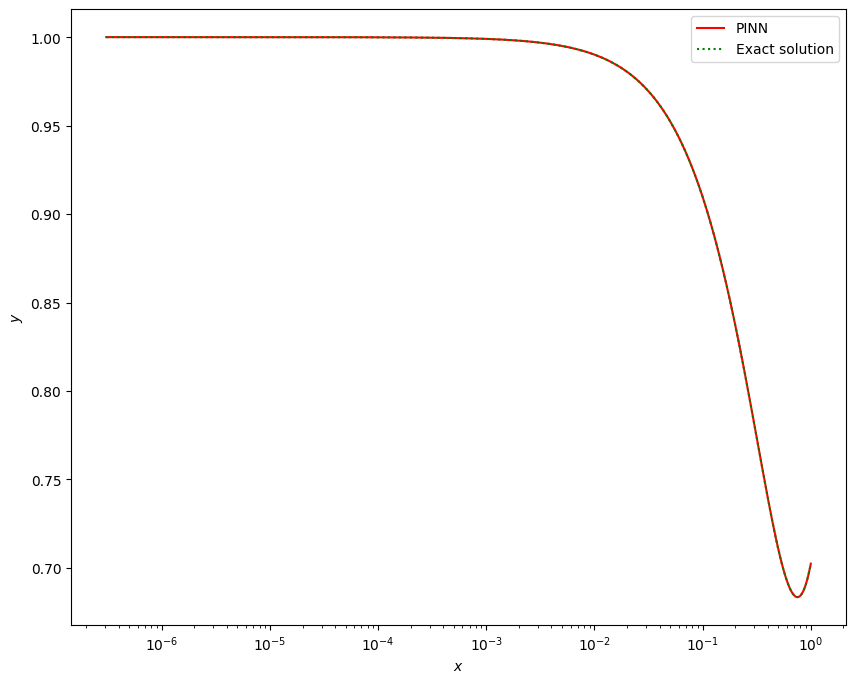

-----------------------------------------
Running for C = 1.6237767391887217
-----------------------------------------
Epoch   0 | Best: 10.000000 | Total: 1.347832 | ODE: 0.050617 | IC: 1.297215
Epoch 10000 | Best: 0.000001 | Total: 0.000001 | ODE: 0.000001 | IC: 0.000000
Epoch 20000 | Best: 0.000000 | Total: 0.000000 | ODE: 0.000000 | IC: 0.000000
Epoch 30000 | Best: 0.000000 | Total: 0.000000 | ODE: 0.000000 | IC: 0.000000
Epoch 40000 | Best: 0.000000 | Total: 0.000000 | ODE: 0.000000 | IC: 0.000000
Epoch 50000 | Best: 0.000000 | Total: 0.000000 | ODE: 0.000000 | IC: 0.000000
Epoch 60000 | Best: 0.000000 | Total: 0.000000 | ODE: 0.000000 | IC: 0.000000
Epoch 70000 | Best: 0.000000 | Total: 0.000000 | ODE: 0.000000 | IC: 0.000000
Epoch 80000 | Best: 0.000000 | Total: 0.000000 | ODE: 0.000000 | IC: 0.000000
Epoch 90000 | Best: 0.000000 | Total: 0.000000 | ODE: 0.000000 | IC: 0.000000


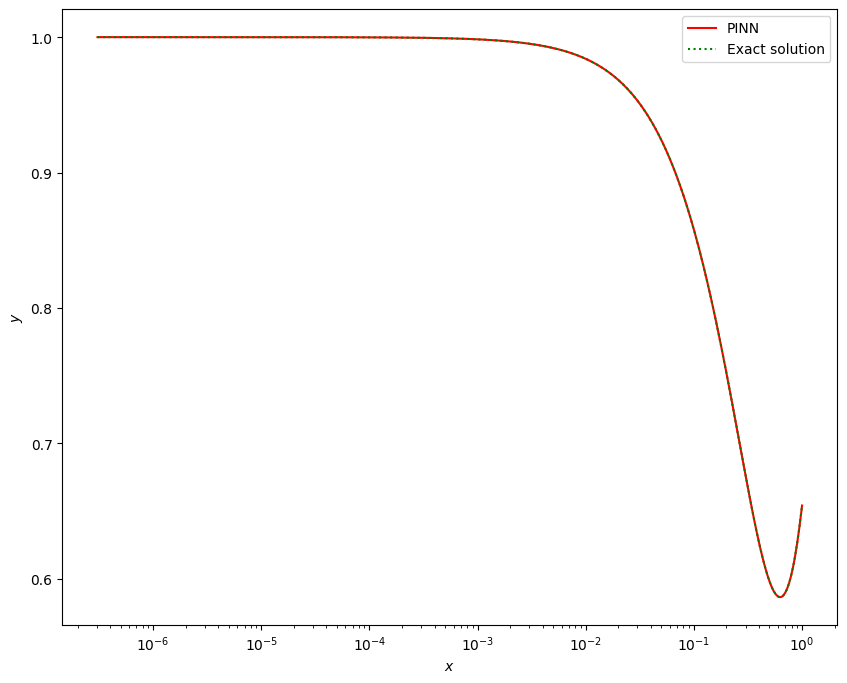

-----------------------------------------
Running for C = 2.636650898730358
-----------------------------------------
Epoch   0 | Best: 10.000000 | Total: 1.267460 | ODE: 0.045881 | IC: 1.221579
Epoch 10000 | Best: 0.000005 | Total: 0.000005 | ODE: 0.000005 | IC: 0.000000
Epoch 20000 | Best: 0.000000 | Total: 0.000000 | ODE: 0.000000 | IC: 0.000000
Epoch 30000 | Best: 0.000000 | Total: 0.000000 | ODE: 0.000000 | IC: 0.000000
Epoch 40000 | Best: 0.000000 | Total: 0.000000 | ODE: 0.000000 | IC: 0.000000
Epoch 50000 | Best: 0.000000 | Total: 0.000000 | ODE: 0.000000 | IC: 0.000000
Epoch 60000 | Best: 0.000000 | Total: 0.000000 | ODE: 0.000000 | IC: 0.000000
Epoch 70000 | Best: 0.000000 | Total: 0.000000 | ODE: 0.000000 | IC: 0.000000
Epoch 80000 | Best: 0.000000 | Total: 0.000000 | ODE: 0.000000 | IC: 0.000000
Epoch 90000 | Best: 0.000000 | Total: 0.000000 | ODE: 0.000000 | IC: 0.000000
Epoch 100000 | Best: 0.000000 | Total: 0.000000 | ODE: 0.000000 | IC: 0.000000
Epoch 110000 | Best: 0.0

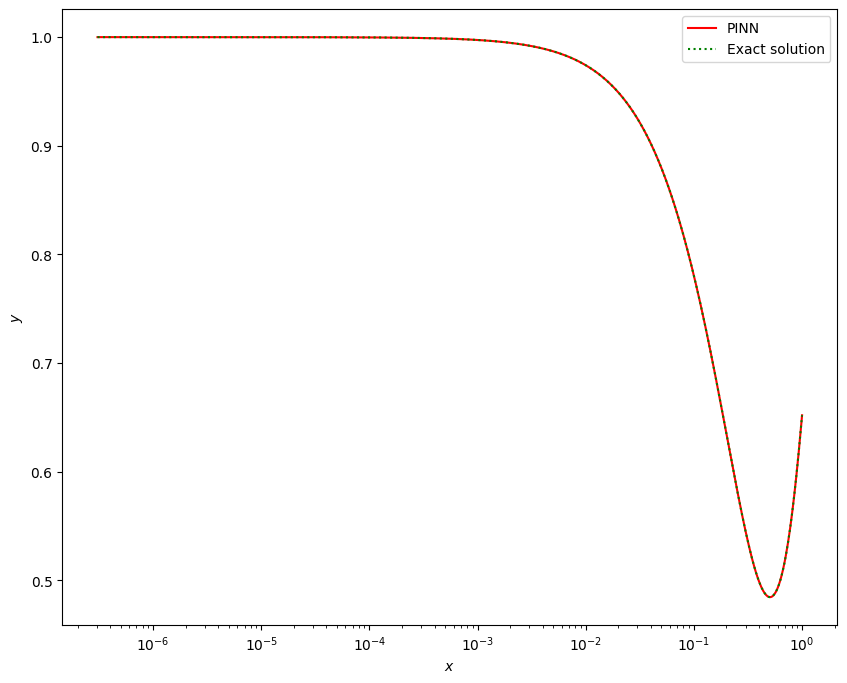

-----------------------------------------
Running for C = 4.281332398719393
-----------------------------------------
Epoch   0 | Best: 10.000000 | Total: 0.987881 | ODE: 0.026293 | IC: 0.961588
Epoch 10000 | Best: 0.000004 | Total: 0.000004 | ODE: 0.000004 | IC: 0.000000
Epoch 20000 | Best: 0.000000 | Total: 0.000000 | ODE: 0.000000 | IC: 0.000000
Epoch 30000 | Best: 0.000000 | Total: 0.000000 | ODE: 0.000000 | IC: 0.000000
Epoch 40000 | Best: 0.000000 | Total: 0.000000 | ODE: 0.000000 | IC: 0.000000
Epoch 50000 | Best: 0.000000 | Total: 0.000000 | ODE: 0.000000 | IC: 0.000000
Epoch 60000 | Best: 0.000000 | Total: 0.000000 | ODE: 0.000000 | IC: 0.000000
Epoch 70000 | Best: 0.000000 | Total: 0.000000 | ODE: 0.000000 | IC: 0.000000
Epoch 80000 | Best: 0.000000 | Total: 0.000000 | ODE: 0.000000 | IC: 0.000000
Epoch 90000 | Best: 0.000000 | Total: 0.000000 | ODE: 0.000000 | IC: 0.000000
Epoch 100000 | Best: 0.000000 | Total: 0.000000 | ODE: 0.000000 | IC: 0.000000
Epoch 110000 | Best: 0.0

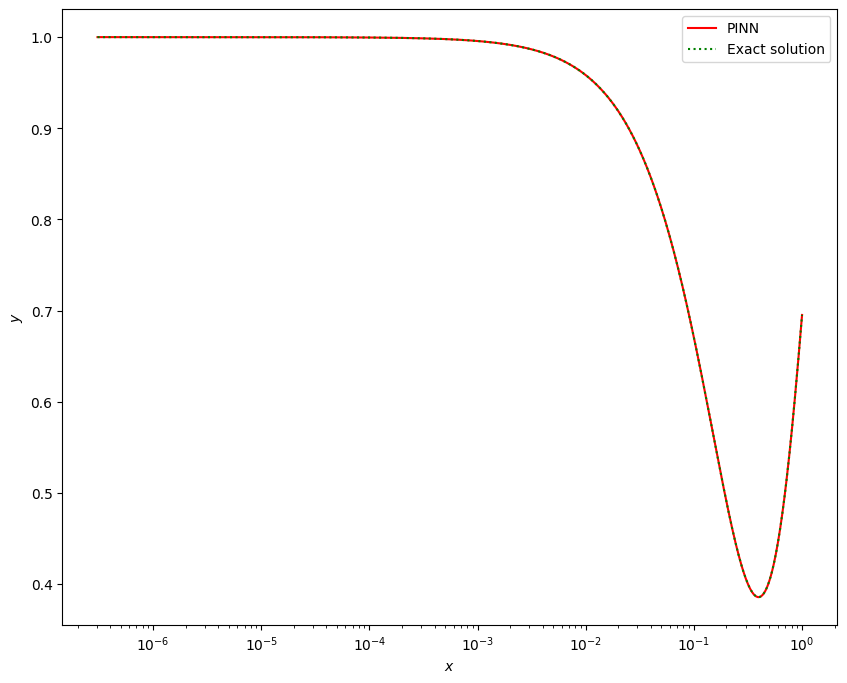

-----------------------------------------
Running for C = 6.951927961775605
-----------------------------------------
Epoch   0 | Best: 10.000000 | Total: 0.873528 | ODE: 0.024285 | IC: 0.849243
Epoch 10000 | Best: 0.000002 | Total: 0.000002 | ODE: 0.000002 | IC: 0.000000
Epoch 20000 | Best: 0.000000 | Total: 0.000000 | ODE: 0.000000 | IC: 0.000000
Epoch 30000 | Best: 0.000000 | Total: 0.000001 | ODE: 0.000000 | IC: 0.000001
Epoch 40000 | Best: 0.000000 | Total: 0.000000 | ODE: 0.000000 | IC: 0.000000
Epoch 50000 | Best: 0.000000 | Total: 0.000000 | ODE: 0.000000 | IC: 0.000000
Epoch 60000 | Best: 0.000000 | Total: 0.000000 | ODE: 0.000000 | IC: 0.000000
Epoch 70000 | Best: 0.000000 | Total: 0.000000 | ODE: 0.000000 | IC: 0.000000
Epoch 80000 | Best: 0.000000 | Total: 0.000000 | ODE: 0.000000 | IC: 0.000000
Epoch 90000 | Best: 0.000000 | Total: 0.000000 | ODE: 0.000000 | IC: 0.000000
Epoch 100000 | Best: 0.000000 | Total: 0.000000 | ODE: 0.000000 | IC: 0.000000
Epoch 110000 | Best: 0.0

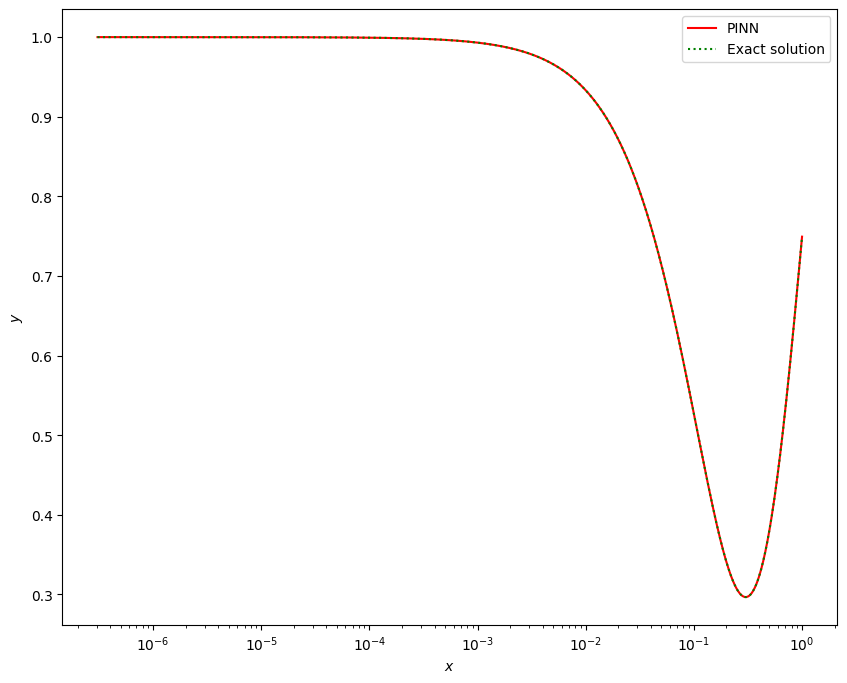

-----------------------------------------
Running for C = 11.28837891684689
-----------------------------------------
Epoch   0 | Best: 10.000000 | Total: 1.184690 | ODE: 0.041919 | IC: 1.142771
Epoch 10000 | Best: 0.000004 | Total: 0.000004 | ODE: 0.000004 | IC: 0.000000
Epoch 20000 | Best: 0.000000 | Total: 0.000000 | ODE: 0.000000 | IC: 0.000000
Epoch 30000 | Best: 0.000000 | Total: 0.000000 | ODE: 0.000000 | IC: 0.000000
Epoch 40000 | Best: 0.000000 | Total: 0.000000 | ODE: 0.000000 | IC: 0.000000
Epoch 50000 | Best: 0.000000 | Total: 0.000000 | ODE: 0.000000 | IC: 0.000000
Epoch 60000 | Best: 0.000000 | Total: 0.000000 | ODE: 0.000000 | IC: 0.000000
Epoch 70000 | Best: 0.000000 | Total: 0.000000 | ODE: 0.000000 | IC: 0.000000
Epoch 80000 | Best: 0.000000 | Total: 0.000000 | ODE: 0.000000 | IC: 0.000000
Epoch 90000 | Best: 0.000000 | Total: 0.000000 | ODE: 0.000000 | IC: 0.000000
Epoch 100000 | Best: 0.000000 | Total: 0.000000 | ODE: 0.000000 | IC: 0.000000
Epoch 110000 | Best: 0.0

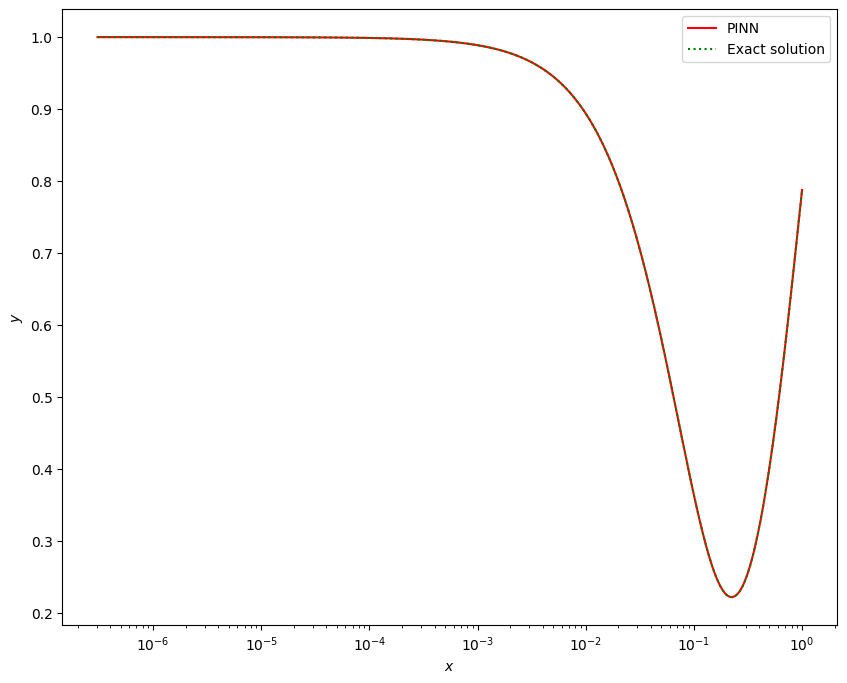

-----------------------------------------
Running for C = 18.329807108324356
-----------------------------------------
Epoch   0 | Best: 10.000000 | Total: 1.398125 | ODE: 0.070198 | IC: 1.327927
Epoch 10000 | Best: 0.000001 | Total: 0.000002 | ODE: 0.000001 | IC: 0.000000
Epoch 20000 | Best: 0.000000 | Total: 0.000000 | ODE: 0.000000 | IC: 0.000000
Epoch 30000 | Best: 0.000000 | Total: 0.000000 | ODE: 0.000000 | IC: 0.000000
Epoch 40000 | Best: 0.000000 | Total: 0.000000 | ODE: 0.000000 | IC: 0.000000
Epoch 50000 | Best: 0.000000 | Total: 0.000001 | ODE: 0.000000 | IC: 0.000001
Epoch 60000 | Best: 0.000000 | Total: 0.000000 | ODE: 0.000000 | IC: 0.000000
Epoch 70000 | Best: 0.000000 | Total: 0.000001 | ODE: 0.000000 | IC: 0.000001
Epoch 80000 | Best: 0.000000 | Total: 0.000000 | ODE: 0.000000 | IC: 0.000000
Epoch 90000 | Best: 0.000000 | Total: 0.000000 | ODE: 0.000000 | IC: 0.000000
Epoch 100000 | Best: 0.000000 | Total: 0.000000 | ODE: 0.000000 | IC: 0.000000
Epoch 110000 | Best: 0.

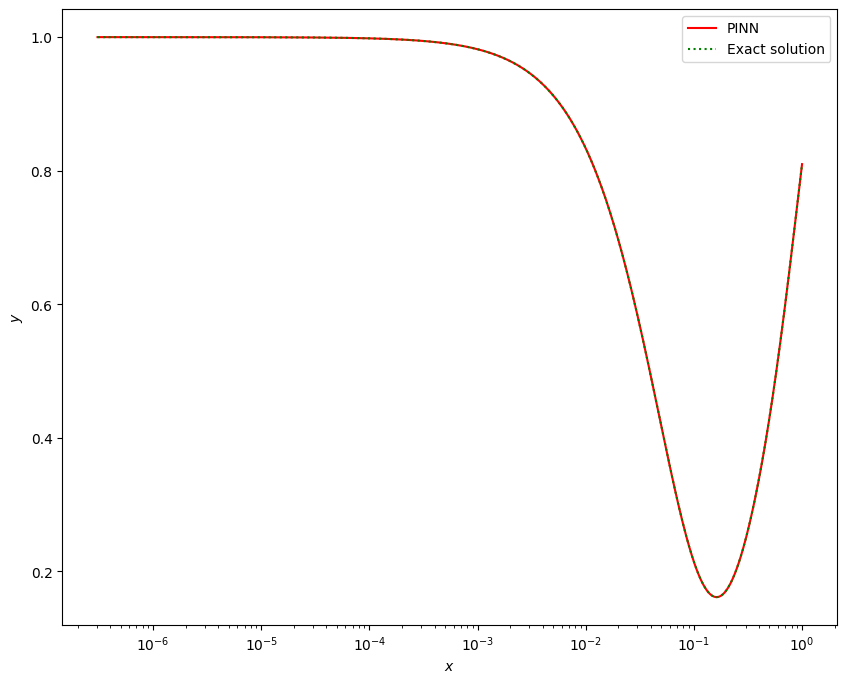

-----------------------------------------
Running for C = 29.763514416313175
-----------------------------------------
Epoch   0 | Best: 10.000000 | Total: 1.159237 | ODE: 0.039820 | IC: 1.119416
Epoch 10000 | Best: 0.000006 | Total: 0.000006 | ODE: 0.000006 | IC: 0.000000
Epoch 20000 | Best: 0.000000 | Total: 0.000000 | ODE: 0.000000 | IC: 0.000000
Epoch 30000 | Best: 0.000000 | Total: 0.000000 | ODE: 0.000000 | IC: 0.000000
Epoch 40000 | Best: 0.000000 | Total: 0.000000 | ODE: 0.000000 | IC: 0.000000
Epoch 50000 | Best: 0.000000 | Total: 0.000000 | ODE: 0.000000 | IC: 0.000000
Epoch 60000 | Best: 0.000000 | Total: 0.000000 | ODE: 0.000000 | IC: 0.000000
Epoch 70000 | Best: 0.000000 | Total: 0.000001 | ODE: 0.000000 | IC: 0.000001
Epoch 80000 | Best: 0.000000 | Total: 0.000000 | ODE: 0.000000 | IC: 0.000000
Epoch 90000 | Best: 0.000000 | Total: 0.000000 | ODE: 0.000000 | IC: 0.000000
Epoch 100000 | Best: 0.000000 | Total: 0.000001 | ODE: 0.000000 | IC: 0.000001
Epoch 110000 | Best: 0.

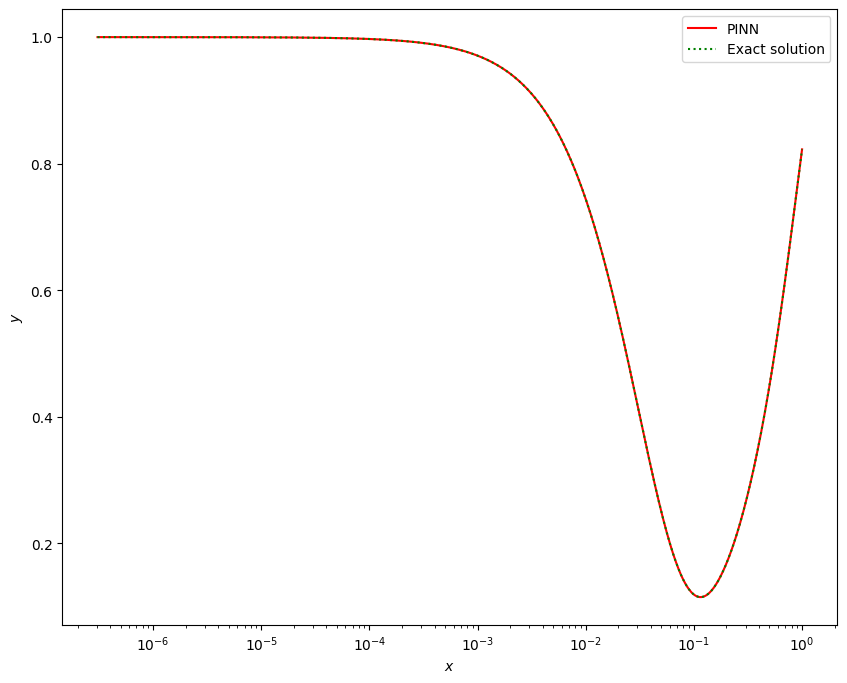

-----------------------------------------
Running for C = 48.32930238571752
-----------------------------------------
Epoch   0 | Best: 10.000000 | Total: 1.065050 | ODE: 0.031473 | IC: 1.033577
Epoch 10000 | Best: 0.000003 | Total: 0.000006 | ODE: 0.000003 | IC: 0.000002
Epoch 20000 | Best: 0.000000 | Total: 0.000000 | ODE: 0.000000 | IC: 0.000000
Epoch 30000 | Best: 0.000000 | Total: 0.000000 | ODE: 0.000000 | IC: 0.000000
Epoch 40000 | Best: 0.000000 | Total: 0.000000 | ODE: 0.000000 | IC: 0.000000
Epoch 50000 | Best: 0.000000 | Total: 0.000000 | ODE: 0.000000 | IC: 0.000000
Epoch 60000 | Best: 0.000000 | Total: 0.000000 | ODE: 0.000000 | IC: 0.000000
Epoch 70000 | Best: 0.000000 | Total: 0.000000 | ODE: 0.000000 | IC: 0.000000
Epoch 80000 | Best: 0.000000 | Total: 0.000000 | ODE: 0.000000 | IC: 0.000000
Epoch 90000 | Best: 0.000000 | Total: 0.000000 | ODE: 0.000000 | IC: 0.000000
Epoch 100000 | Best: 0.000000 | Total: 0.000000 | ODE: 0.000000 | IC: 0.000000
Epoch 110000 | Best: 0.0

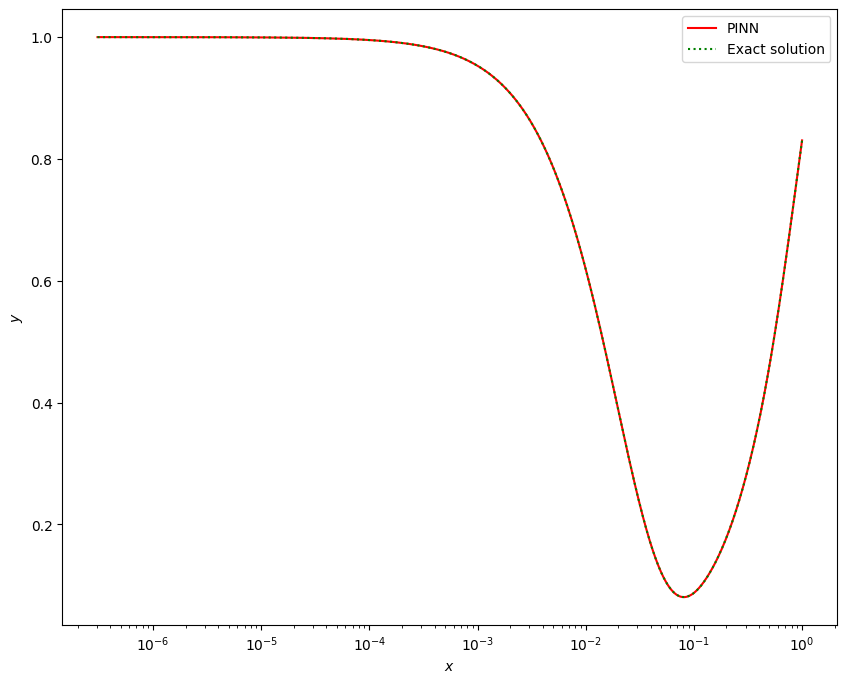

-----------------------------------------
Running for C = 78.47599703514611
-----------------------------------------
Epoch   0 | Best: 10.000000 | Total: 1.300867 | ODE: 0.056279 | IC: 1.244588
Epoch 10000 | Best: 0.000022 | Total: 0.000022 | ODE: 0.000022 | IC: 0.000000
Epoch 20000 | Best: 0.000001 | Total: 0.000001 | ODE: 0.000001 | IC: 0.000000
Epoch 30000 | Best: 0.000000 | Total: 0.000000 | ODE: 0.000000 | IC: 0.000000
Epoch 40000 | Best: 0.000000 | Total: 0.000000 | ODE: 0.000000 | IC: 0.000000
Epoch 50000 | Best: 0.000000 | Total: 0.000000 | ODE: 0.000000 | IC: 0.000000
Epoch 60000 | Best: 0.000000 | Total: 0.000009 | ODE: 0.000000 | IC: 0.000009
Epoch 70000 | Best: 0.000000 | Total: 0.000000 | ODE: 0.000000 | IC: 0.000000
Epoch 80000 | Best: 0.000000 | Total: 0.000000 | ODE: 0.000000 | IC: 0.000000
Epoch 90000 | Best: 0.000000 | Total: 0.000000 | ODE: 0.000000 | IC: 0.000000
Epoch 100000 | Best: 0.000000 | Total: 0.000000 | ODE: 0.000000 | IC: 0.000000
Epoch 110000 | Best: 0.0

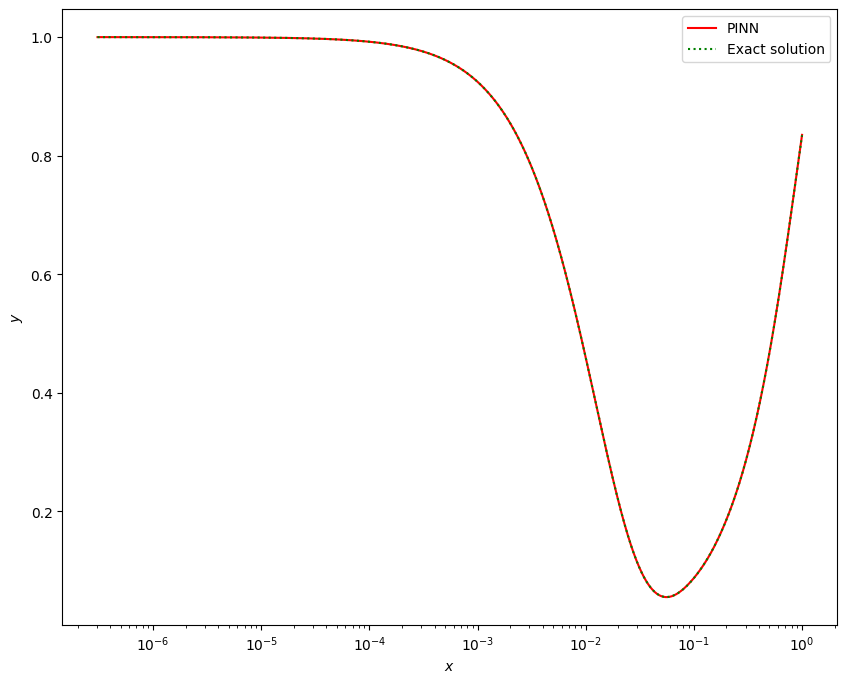

-----------------------------------------
Running for C = 127.42749857031335
-----------------------------------------
Epoch   0 | Best: 10.000000 | Total: 1.405991 | ODE: 0.071852 | IC: 1.334139
Epoch 10000 | Best: 0.000024 | Total: 0.000046 | ODE: 0.000025 | IC: 0.000021
Epoch 20000 | Best: 0.000002 | Total: 0.000003 | ODE: 0.000002 | IC: 0.000001
Epoch 30000 | Best: 0.000001 | Total: 0.000001 | ODE: 0.000001 | IC: 0.000000
Epoch 40000 | Best: 0.000001 | Total: 0.000001 | ODE: 0.000001 | IC: 0.000000
Epoch 50000 | Best: 0.000001 | Total: 0.000001 | ODE: 0.000001 | IC: 0.000000
Epoch 60000 | Best: 0.000000 | Total: 0.000000 | ODE: 0.000000 | IC: 0.000000
Epoch 70000 | Best: 0.000000 | Total: 0.000000 | ODE: 0.000000 | IC: 0.000000
Epoch 80000 | Best: 0.000000 | Total: 0.000001 | ODE: 0.000000 | IC: 0.000001
Epoch 90000 | Best: 0.000000 | Total: 0.000000 | ODE: 0.000000 | IC: 0.000000
Epoch 100000 | Best: 0.000000 | Total: 0.000000 | ODE: 0.000000 | IC: 0.000000
Epoch 110000 | Best: 0.

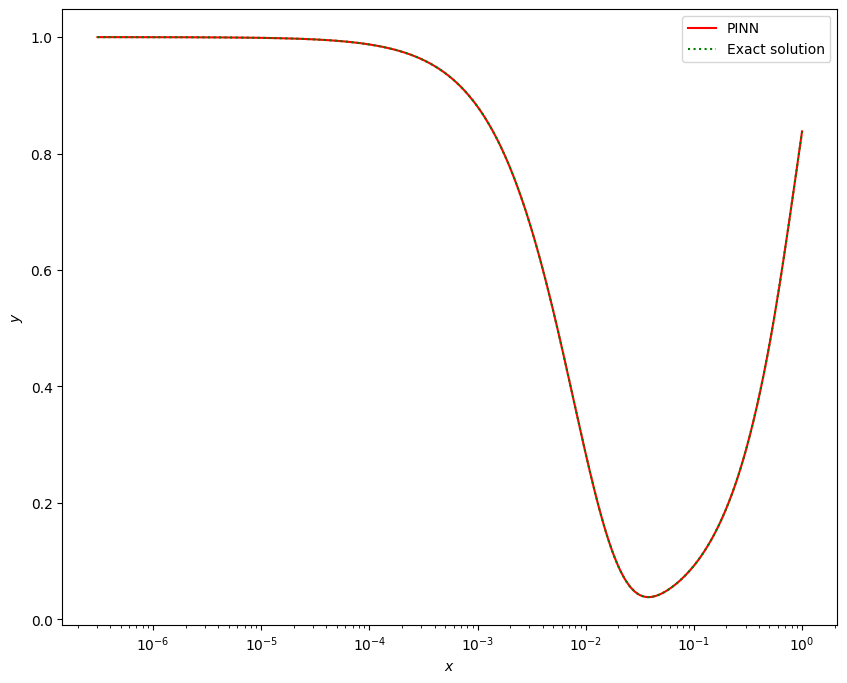

-----------------------------------------
Running for C = 206.913808111479
-----------------------------------------
Epoch   0 | Best: 10.000000 | Total: 0.927422 | ODE: 0.024529 | IC: 0.902893
Epoch 10000 | Best: 0.000110 | Total: 0.000110 | ODE: 0.000110 | IC: 0.000000
Epoch 20000 | Best: 0.000006 | Total: 0.000040 | ODE: 0.000007 | IC: 0.000033
Epoch 30000 | Best: 0.000002 | Total: 0.000002 | ODE: 0.000002 | IC: 0.000000
Epoch 40000 | Best: 0.000001 | Total: 0.000009 | ODE: 0.000001 | IC: 0.000008
Epoch 50000 | Best: 0.000001 | Total: 0.000008 | ODE: 0.000001 | IC: 0.000007
Epoch 60000 | Best: 0.000001 | Total: 0.000002 | ODE: 0.000001 | IC: 0.000001
Epoch 70000 | Best: 0.000001 | Total: 0.000001 | ODE: 0.000001 | IC: 0.000000
Epoch 80000 | Best: 0.000001 | Total: 0.000001 | ODE: 0.000001 | IC: 0.000000
Epoch 90000 | Best: 0.000001 | Total: 0.000001 | ODE: 0.000001 | IC: 0.000000
Epoch 100000 | Best: 0.000001 | Total: 0.000001 | ODE: 0.000001 | IC: 0.000000
Epoch 110000 | Best: 0.00

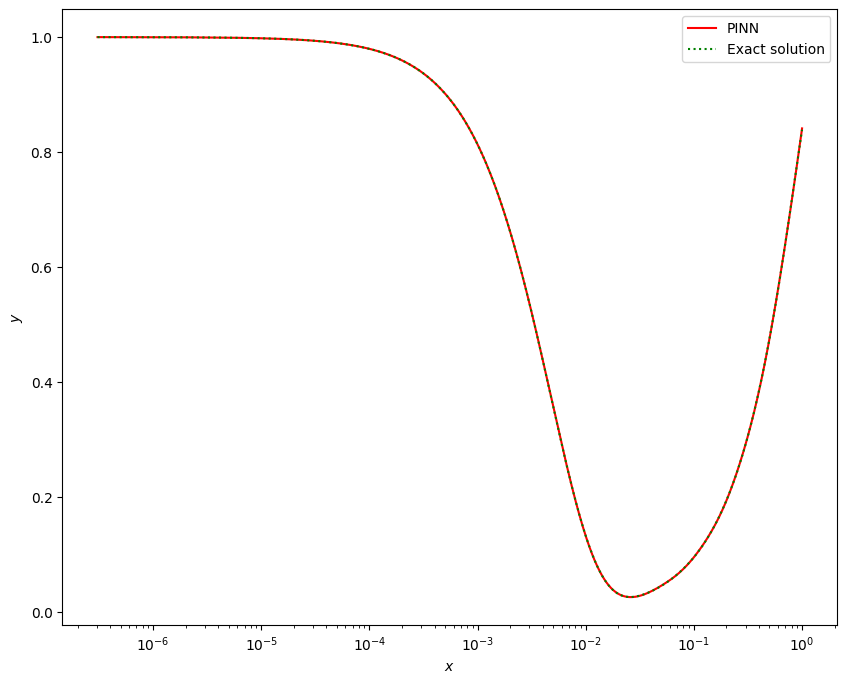

-----------------------------------------
Running for C = 335.9818286283781
-----------------------------------------
Epoch   0 | Best: 10.000000 | Total: 0.796476 | ODE: 0.028098 | IC: 0.768378
Epoch 10000 | Best: 0.000348 | Total: 0.000353 | ODE: 0.000351 | IC: 0.000002
Epoch 20000 | Best: 0.000007 | Total: 0.000007 | ODE: 0.000006 | IC: 0.000000
Epoch 30000 | Best: 0.000003 | Total: 0.000003 | ODE: 0.000003 | IC: 0.000000
Epoch 40000 | Best: 0.000002 | Total: 0.000002 | ODE: 0.000002 | IC: 0.000000
Epoch 50000 | Best: 0.000001 | Total: 0.000001 | ODE: 0.000001 | IC: 0.000000
Epoch 60000 | Best: 0.000001 | Total: 0.000005 | ODE: 0.000001 | IC: 0.000004
Epoch 70000 | Best: 0.000001 | Total: 0.000001 | ODE: 0.000001 | IC: 0.000000
Epoch 80000 | Best: 0.000001 | Total: 0.000001 | ODE: 0.000001 | IC: 0.000000
Epoch 90000 | Best: 0.000001 | Total: 0.000001 | ODE: 0.000001 | IC: 0.000000
Epoch 100000 | Best: 0.000001 | Total: 0.000001 | ODE: 0.000001 | IC: 0.000000
Epoch 110000 | Best: 0.0

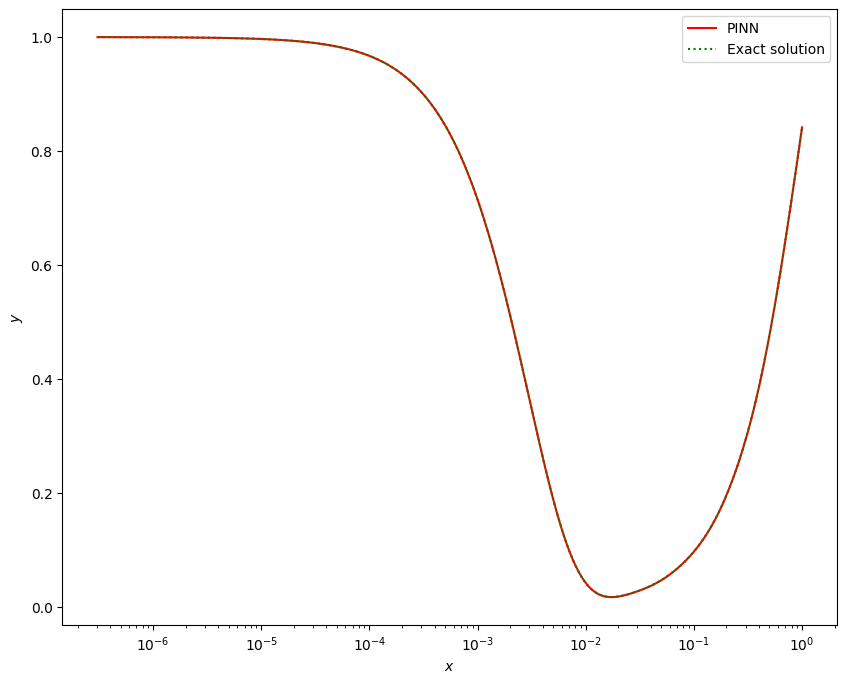

-----------------------------------------
Running for C = 545.5594781168514
-----------------------------------------
Epoch   0 | Best: 10.000000 | Total: 0.879323 | ODE: 0.025021 | IC: 0.854303
Epoch 10000 | Best: 0.002290 | Total: 0.002339 | ODE: 0.002337 | IC: 0.000003
Epoch 20000 | Best: 0.000025 | Total: 0.000025 | ODE: 0.000025 | IC: 0.000000
Epoch 30000 | Best: 0.000003 | Total: 0.000064 | ODE: 0.000004 | IC: 0.000061
Epoch 40000 | Best: 0.000002 | Total: 0.000002 | ODE: 0.000002 | IC: 0.000000
Epoch 50000 | Best: 0.000001 | Total: 0.000001 | ODE: 0.000001 | IC: 0.000000
Epoch 60000 | Best: 0.000001 | Total: 0.000007 | ODE: 0.000001 | IC: 0.000006
Epoch 70000 | Best: 0.000001 | Total: 0.000001 | ODE: 0.000001 | IC: 0.000000
Epoch 80000 | Best: 0.000001 | Total: 0.000078 | ODE: 0.000001 | IC: 0.000077
Epoch 90000 | Best: 0.000001 | Total: 0.000001 | ODE: 0.000001 | IC: 0.000000
Epoch 100000 | Best: 0.000001 | Total: 0.000007 | ODE: 0.000001 | IC: 0.000006
Epoch 110000 | Best: 0.0

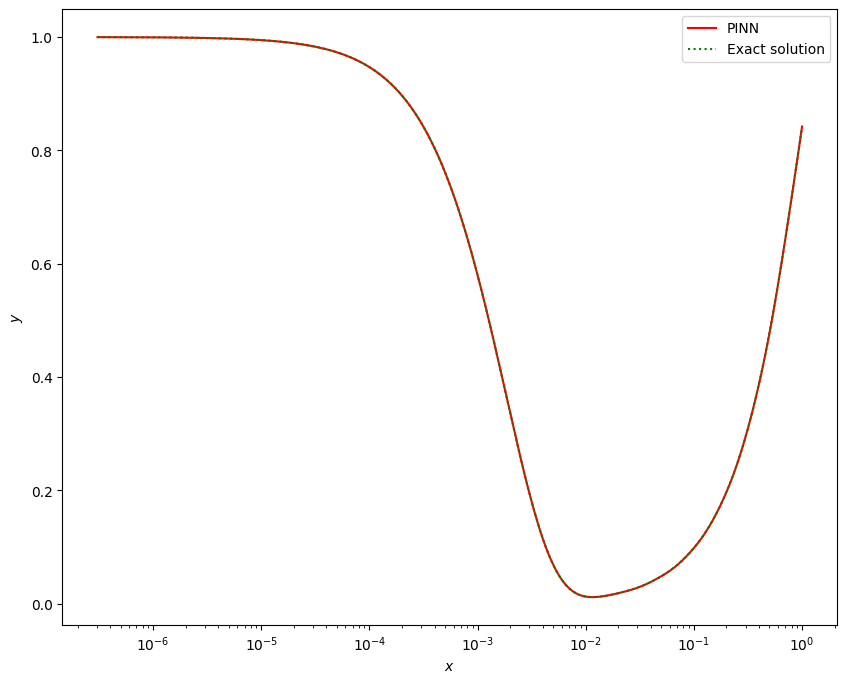

-----------------------------------------
Running for C = 885.8667904100823
-----------------------------------------
Epoch   0 | Best: 10.000000 | Total: 1.322894 | ODE: 0.059729 | IC: 1.263165
Epoch 10000 | Best: 0.030642 | Total: 0.031369 | ODE: 0.030832 | IC: 0.000538
Epoch 20000 | Best: 0.000392 | Total: 0.000391 | ODE: 0.000391 | IC: 0.000000
Epoch 30000 | Best: 0.000024 | Total: 0.000076 | ODE: 0.000025 | IC: 0.000051
Epoch 40000 | Best: 0.000011 | Total: 0.000011 | ODE: 0.000011 | IC: 0.000000
Epoch 50000 | Best: 0.000008 | Total: 0.000010 | ODE: 0.000008 | IC: 0.000002
Epoch 60000 | Best: 0.000006 | Total: 0.000006 | ODE: 0.000006 | IC: 0.000000
Epoch 70000 | Best: 0.000005 | Total: 0.000005 | ODE: 0.000005 | IC: 0.000000
Epoch 80000 | Best: 0.000004 | Total: 0.000004 | ODE: 0.000004 | IC: 0.000000
Epoch 90000 | Best: 0.000003 | Total: 0.000004 | ODE: 0.000003 | IC: 0.000000
Epoch 100000 | Best: 0.000003 | Total: 0.000003 | ODE: 0.000003 | IC: 0.000000
Epoch 110000 | Best: 0.0

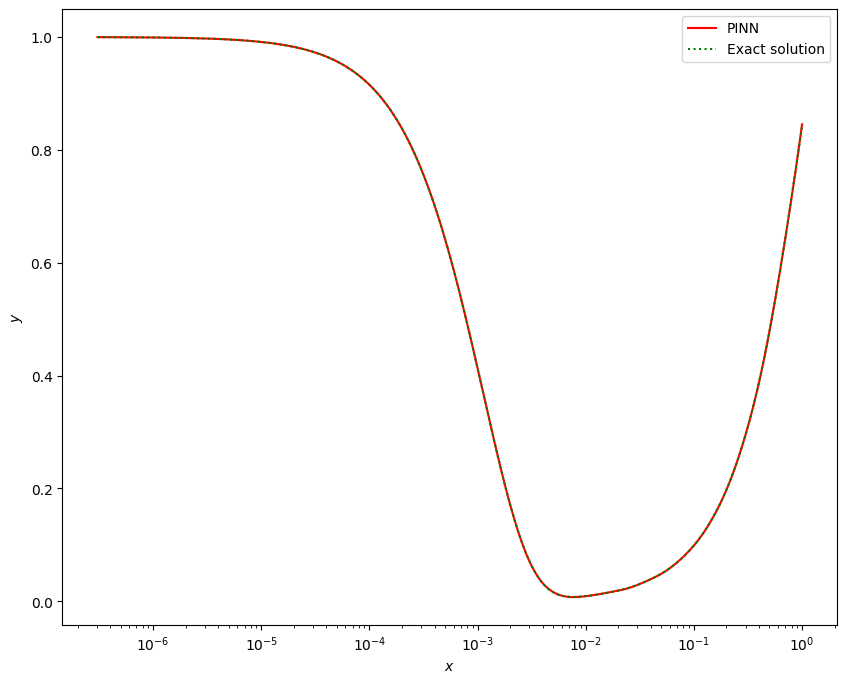

-----------------------------------------
Running for C = 1438.449888287663
-----------------------------------------
Epoch   0 | Best: 10.000000 | Total: 0.732371 | ODE: 0.035096 | IC: 0.697275
Epoch 10000 | Best: 0.029151 | Total: 0.029125 | ODE: 0.027012 | IC: 0.002113
Epoch 20000 | Best: 0.000836 | Total: 0.000889 | ODE: 0.000857 | IC: 0.000032
Epoch 30000 | Best: 0.000095 | Total: 0.000095 | ODE: 0.000095 | IC: 0.000000
Epoch 40000 | Best: 0.000033 | Total: 0.000034 | ODE: 0.000033 | IC: 0.000000
Epoch 50000 | Best: 0.000014 | Total: 0.000318 | ODE: 0.000015 | IC: 0.000303
Epoch 60000 | Best: 0.000008 | Total: 0.000043 | ODE: 0.000008 | IC: 0.000035
Epoch 70000 | Best: 0.000005 | Total: 0.000046 | ODE: 0.000005 | IC: 0.000041
Epoch 80000 | Best: 0.000004 | Total: 0.000043 | ODE: 0.000004 | IC: 0.000039
Epoch 90000 | Best: 0.000003 | Total: 0.000004 | ODE: 0.000003 | IC: 0.000000
Epoch 100000 | Best: 0.000003 | Total: 0.000003 | ODE: 0.000003 | IC: 0.000000
Epoch 110000 | Best: 0.0

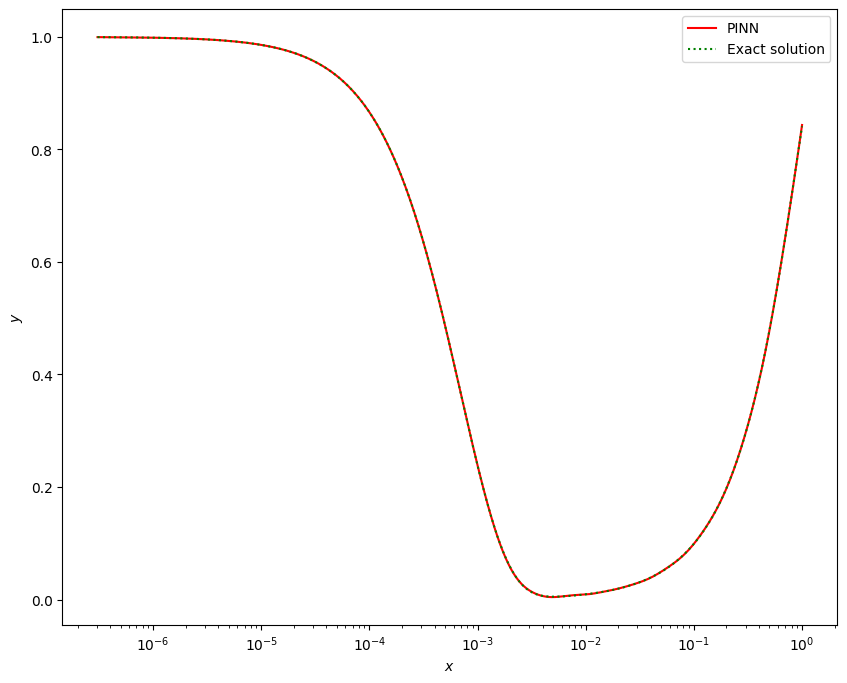

-----------------------------------------
Running for C = 2335.7214690901214
-----------------------------------------
Epoch   0 | Best: 10.000000 | Total: 1.235032 | ODE: 0.048026 | IC: 1.187006
Epoch 10000 | Best: 0.135815 | Total: 0.135766 | ODE: 0.108230 | IC: 0.027537
Epoch 20000 | Best: 0.009813 | Total: 0.009819 | ODE: 0.009343 | IC: 0.000476
Epoch 30000 | Best: 0.001107 | Total: 0.001106 | ODE: 0.001099 | IC: 0.000008
Epoch 40000 | Best: 0.000181 | Total: 0.000183 | ODE: 0.000179 | IC: 0.000004
Epoch 50000 | Best: 0.000043 | Total: 0.000043 | ODE: 0.000043 | IC: 0.000000
Epoch 60000 | Best: 0.000017 | Total: 0.000017 | ODE: 0.000017 | IC: 0.000000
Epoch 70000 | Best: 0.000010 | Total: 0.000011 | ODE: 0.000010 | IC: 0.000001
Epoch 80000 | Best: 0.000007 | Total: 0.000008 | ODE: 0.000007 | IC: 0.000001
Epoch 90000 | Best: 0.000006 | Total: 0.000007 | ODE: 0.000006 | IC: 0.000001
Epoch 100000 | Best: 0.000005 | Total: 0.000012 | ODE: 0.000005 | IC: 0.000007
Epoch 110000 | Best: 0.

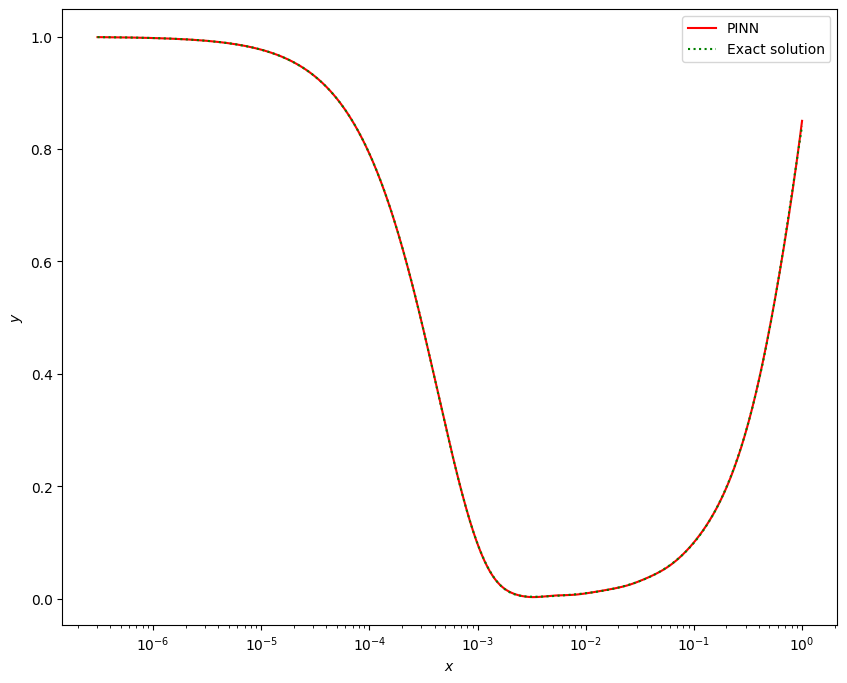

-----------------------------------------
Running for C = 3792.690190732246
-----------------------------------------
Epoch   0 | Best: 10.000000 | Total: 1.103569 | ODE: 0.034650 | IC: 1.068919
Epoch 10000 | Best: 0.354079 | Total: 0.354074 | ODE: 0.221765 | IC: 0.132309
Epoch 20000 | Best: 0.084197 | Total: 0.084174 | ODE: 0.069879 | IC: 0.014294
Epoch 30000 | Best: 0.009609 | Total: 0.009606 | ODE: 0.009291 | IC: 0.000315
Epoch 40000 | Best: 0.001520 | Total: 0.002661 | ODE: 0.001870 | IC: 0.000791
Epoch 50000 | Best: 0.000320 | Total: 0.000320 | ODE: 0.000320 | IC: 0.000000
Epoch 60000 | Best: 0.000103 | Total: 0.000118 | ODE: 0.000101 | IC: 0.000016
Epoch 70000 | Best: 0.000048 | Total: 0.000052 | ODE: 0.000048 | IC: 0.000003
Epoch 80000 | Best: 0.000033 | Total: 0.000033 | ODE: 0.000033 | IC: 0.000000
Epoch 90000 | Best: 0.000026 | Total: 0.000361 | ODE: 0.000059 | IC: 0.000303
Epoch 100000 | Best: 0.000022 | Total: 0.000160 | ODE: 0.000035 | IC: 0.000125
Epoch 110000 | Best: 0.0

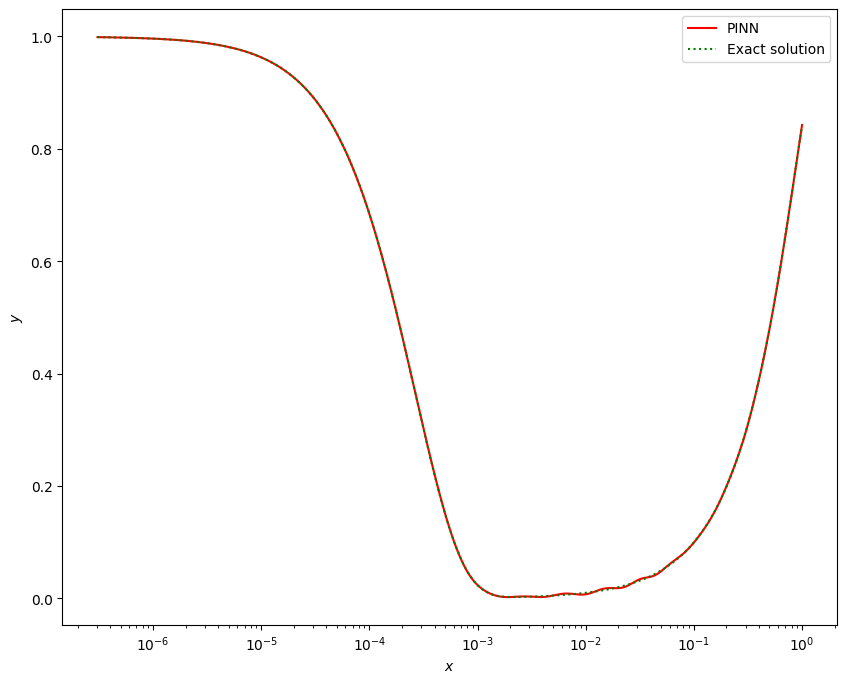

-----------------------------------------
Running for C = 6158.48211066026
-----------------------------------------
Epoch   0 | Best: 10.000000 | Total: 1.194046 | ODE: 0.043989 | IC: 1.150057
Epoch 10000 | Best: 0.296124 | Total: 0.296108 | ODE: 0.198864 | IC: 0.097245
Epoch 20000 | Best: 0.133349 | Total: 0.133342 | ODE: 0.106966 | IC: 0.026377
Epoch 30000 | Best: 0.039636 | Total: 0.039630 | ODE: 0.035855 | IC: 0.003775
Epoch 40000 | Best: 0.010021 | Total: 0.010084 | ODE: 0.009347 | IC: 0.000737
Epoch 50000 | Best: 0.002738 | Total: 0.002746 | ODE: 0.002738 | IC: 0.000008
Epoch 60000 | Best: 0.000963 | Total: 0.001074 | ODE: 0.000915 | IC: 0.000159
Epoch 70000 | Best: 0.000412 | Total: 0.000412 | ODE: 0.000411 | IC: 0.000001
Epoch 80000 | Best: 0.000179 | Total: 0.000179 | ODE: 0.000179 | IC: 0.000000
Epoch 90000 | Best: 0.000076 | Total: 0.000122 | ODE: 0.000073 | IC: 0.000048
Epoch 100000 | Best: 0.000043 | Total: 0.000069 | ODE: 0.000042 | IC: 0.000027
Epoch 110000 | Best: 0.00

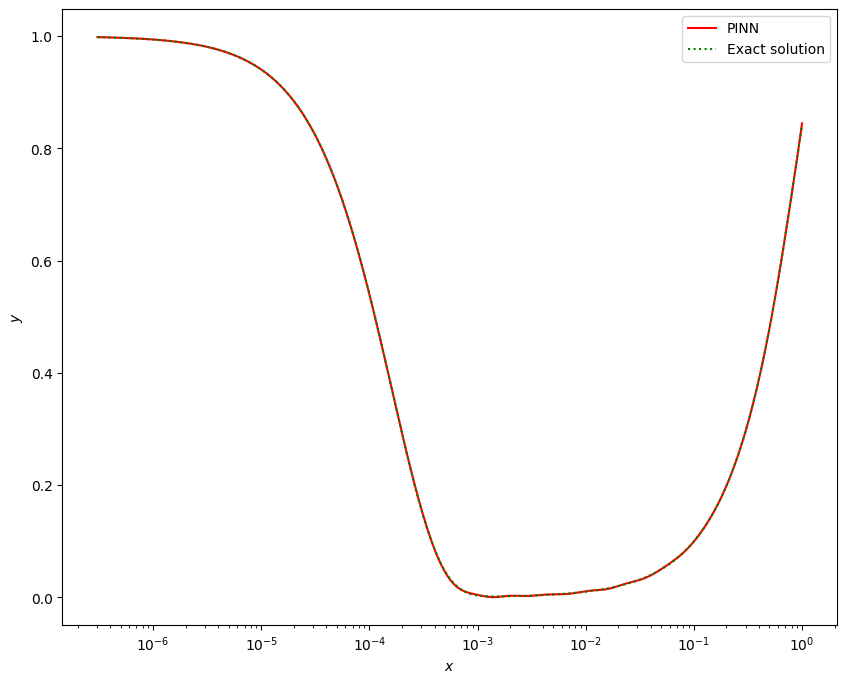

-----------------------------------------
Running for C = 10000.0
-----------------------------------------
Epoch   0 | Best: 10.000000 | Total: 1.105904 | ODE: 0.035049 | IC: 1.070855
Epoch 10000 | Best: 0.273669 | Total: 0.273656 | ODE: 0.191059 | IC: 0.082597
Epoch 20000 | Best: 0.165672 | Total: 0.165654 | ODE: 0.132141 | IC: 0.033512
Epoch 30000 | Best: 0.083709 | Total: 0.083703 | ODE: 0.073187 | IC: 0.010516
Epoch 40000 | Best: 0.040429 | Total: 0.040779 | ODE: 0.039327 | IC: 0.001452
Epoch 50000 | Best: 0.018461 | Total: 0.018510 | ODE: 0.018107 | IC: 0.000403
Epoch 60000 | Best: 0.008883 | Total: 0.008883 | ODE: 0.008634 | IC: 0.000249
Epoch 70000 | Best: 0.004186 | Total: 0.004186 | ODE: 0.004136 | IC: 0.000051
Epoch 80000 | Best: 0.002114 | Total: 0.002192 | ODE: 0.002029 | IC: 0.000162
Epoch 90000 | Best: 0.001031 | Total: 0.001031 | ODE: 0.001027 | IC: 0.000004
Epoch 100000 | Best: 0.000507 | Total: 0.000519 | ODE: 0.000500 | IC: 0.000020
Epoch 110000 | Best: 0.000317 | To

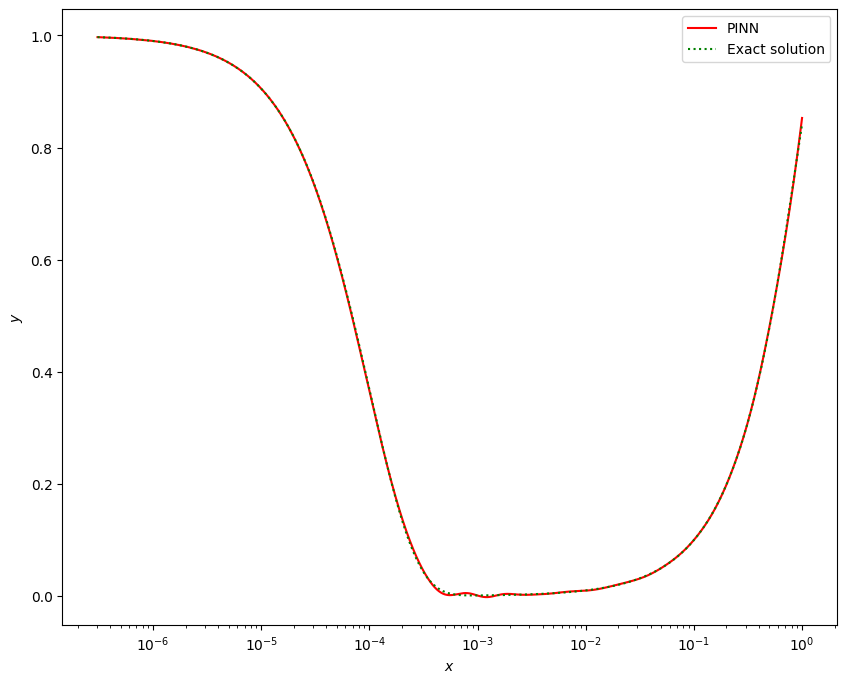

In [7]:
lst_eig_max = experiment(C_test, n_epochs)

## Maximum eigenvalues

In [8]:
# Print list of maximum hessian eigenvalues
print("Eigenvalue list:")
print([round(x, 2) for x in lst_eig_max])

Eigenvalue list:
[5.29, 6.07, 7.95, 7.84, 10.56, 11.55, 11.34, 20.43, 14.16, 30.5, 29.14, 52.69, 41.33, 80.65, 97.91, 103.46, 196.91, 9229.42, 593.49, 1459.6]
